In [14]:
import os
import sys
import importlib

repo_name = 'MCMC-MonteCarlo-TFG'
repo_url = f'https://github.com/mateoveega/{repo_name}.git'
repo_path = f'/content/{repo_name}'

if not os.path.exists(repo_path):
    !git clone {repo_url}
else:
    %cd {repo_path}
    !git pull
    %cd /content

if repo_path not in sys.path:
    sys.path.append(repo_path)

import aux
importlib.reload(aux)
from aux import pdf_objetivo_rechazo, pdf_envolvente_rechazo
import samplers
importlib.reload(samplers)
from samplers import box_muller, rechazo

from google.colab import files
import numpy as np
import matplotlib.pyplot as plt

/content/MCMC-MonteCarlo-TFG
Already up to date.
/content


In [22]:
rango_x = np.linspace(-7, 7, 1000)
muestreador = lambda n: 0.5 + 3 * box_muller(1, n).flatten()
cociente = pdf_objetivo_rechazo(rango_x) / pdf_envolvente_rechazo(rango_x)
k = np.max(cociente)
num_muestras = 100000

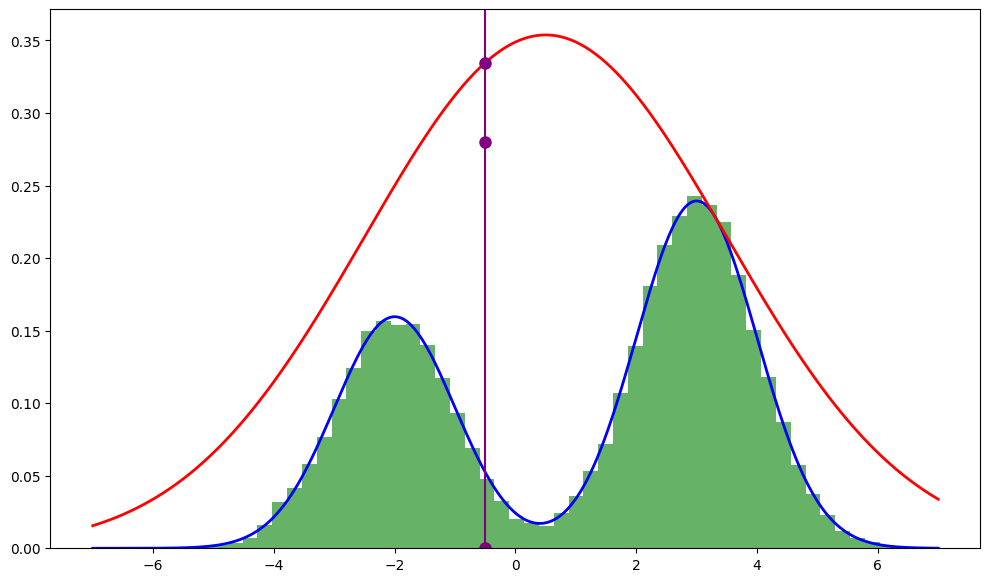

In [23]:
muestras_aceptadas, muestras_rechazadas = rechazo(pdf_objetivo_rechazo, pdf_envolvente_rechazo, muestreador, k, num_muestras)

plt.figure(figsize=(12, 7))
x_grafico = np.linspace(-7, 7, 500)

plt.plot(x_grafico, pdf_objetivo_rechazo(x_grafico), label='Distribución Objetivo Bimodal', color='blue', linewidth=2)
plt.plot(x_grafico, k * pdf_envolvente_rechazo(x_grafico), color='red', linewidth=2)
plt.hist(muestras_aceptadas, bins=50, density=True, alpha=0.6, color='green')

x0 = -0.5
y_en_x0 = k * pdf_envolvente_rechazo(x0)
y0 = 0.28

plt.axvline(x=x0, color='purple', linewidth=1.5, label=f'Línea en x_0 = {x0}')

plt.plot(x0, y_en_x0, 'o', color='purple', markersize=8)
plt.plot(x0, y0, 'o', color='purple', markersize=8)
plt.plot(x0, 0, 'o', color='purple', markersize=8)
plt.ylim(bottom=0)

plt.savefig("RECHAZO.pdf")
plt.show()

In [24]:
from google.colab import files
files.download("RECHAZO.pdf")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>